# Paper Figures: h-network gamma extraction

1. Corner plot (matched 25 vs 25)
2. Varying B± pseudo-data comparison
3. C and S² heatmaps: isobar model vs h-network

## Optional: Download required data

Set `DOWNLOAD = True` to fetch only the files needed for these figures from the repository. This avoids cloning the full repo (~2 GB).

In [ ]:
import os, urllib.request

DOWNLOAD = False  # Set to True to download required files
DOWNLOAD_DIR = 'paper_figures_data'

REPO_RAW = 'https://raw.githubusercontent.com/tonymenzo/ml_gamma_extraction/main'

# Files needed for all three figures
REQUIRED_FILES = {
    # Core physics code
    'Amplitude.py': f'{REPO_RAW}/Amplitude.py',
    'DKpp.py': f'{REPO_RAW}/DKpp.py',
    'models/__init__.py': None,  # empty, created locally
    'models/h_network/__init__.py': f'{REPO_RAW}/models/h_network/__init__.py',
    'models/h_network/models.py': f'{REPO_RAW}/models/h_network/models.py',
    # Results (corner plot + varying Bdata)
    'models/h_network/results/amplitude_model_fit.npz': f'{REPO_RAW}/models/h_network/results/amplitude_model_fit.npz',
    'models/h_network/results/ensemble_comparison_symmetric_results_v2.json': f'{REPO_RAW}/models/h_network/results/ensemble_comparison_symmetric_results_v2.json',
    'models/h_network/results/fit_results_4_15.npz': f'{REPO_RAW}/models/h_network/results/fit_results_4_15.npz',
    'models/h_network/results/varying_Bdata_hnet.json': f'{REPO_RAW}/models/h_network/results/varying_Bdata_hnet.json',
    # Weights for C/S² heatmaps (seed 1)
    'models/flavor_flow/weights/trial_seed1.pth': f'{REPO_RAW}/models/flavor_flow/weights/trial_seed1.pth',
    'models/h_network/weights/h_ensemble_sym_seed1.pth': f'{REPO_RAW}/models/h_network/weights/h_ensemble_sym_seed1.pth',
}

if DOWNLOAD:
    for local_path, url in REQUIRED_FILES.items():
        full_path = os.path.join(DOWNLOAD_DIR, local_path)
        os.makedirs(os.path.dirname(full_path), exist_ok=True)
        if url is None:
            open(full_path, 'w').close()  # empty __init__.py
        elif not os.path.exists(full_path):
            print(f'Downloading {local_path}...', end=' ')
            urllib.request.urlretrieve(url, full_path)
            print('done')
        else:
            print(f'Already exists: {local_path}')
    REPO_ROOT = DOWNLOAD_DIR
    print(f'\nAll files downloaded to {DOWNLOAD_DIR}/')
else:
    # Assumes notebook is run from models/h_network/analysis/ within the repo
    REPO_ROOT = os.path.join(os.path.abspath(''), '..', '..', '..')

In [1]:
import numpy as np
import json, os, sys
import torch
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

# Use REPO_ROOT from the download cell, or default to local repo structure
if 'REPO_ROOT' not in dir():
    REPO_ROOT = os.path.join(os.path.abspath(''), '..', '..', '..')

ROOT = os.path.abspath(REPO_ROOT)
H_DIR = os.path.join(ROOT, 'models', 'h_network')
RESULTS_DIR = os.path.join(H_DIR, 'results')
FIGURES_DIR = os.path.join(H_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
sys.path.insert(0, ROOT)

from Amplitude import SquareDalitzPlot2
from DKpp import DKpp
from models.h_network.models import create_flow, SymmetricSIREN

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}',
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 150,
})

# Physics
M_D0, m_KS, m_pip, m_pim = 1.86484, 0.497611, 0.13957, 0.13957
sdp_obj = SquareDalitzPlot2(M_D0, m_KS, m_pip, m_pim)
IDX = (2, 3, 1)
S_TOTAL = M_D0**2 + m_KS**2 + 2 * m_pip**2
true_rB, true_delta, true_gamma = 0.1, 130.0, 70.0

print(f'Repository root: {ROOT}')
print(f'Results dir: {RESULTS_DIR}')
print(f'Figures dir: {FIGURES_DIR}')

Repository root: /Users/ynot/code/research/ml_gamma_extraction
Results dir: /Users/ynot/code/research/ml_gamma_extraction/models/h_network/results
Figures dir: /Users/ynot/code/research/ml_gamma_extraction/models/h_network/figures


## 1. Corner Plot (25 vs 25, matched datasets)

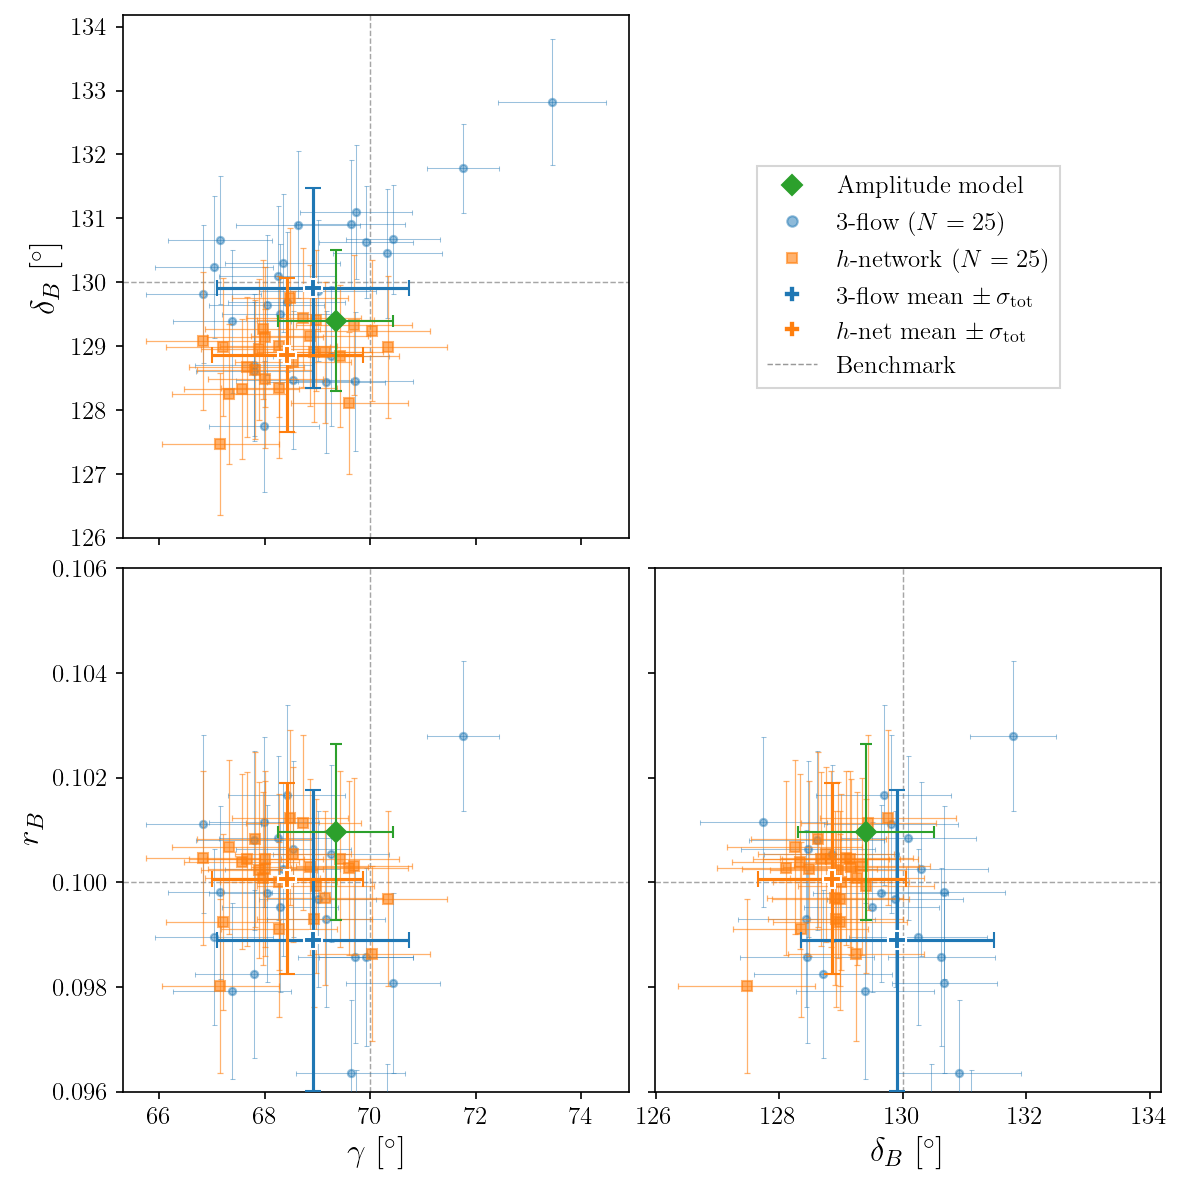

In [2]:
am = np.load(os.path.join(RESULTS_DIR, 'amplitude_model_fit.npz'))
h_results = json.load(open(os.path.join(RESULTS_DIR, 'ensemble_comparison_symmetric_results_v2.json')))
d = np.load(os.path.join(RESULTS_DIR, 'fit_results_4_15.npz'))
seeds = [r['seed'] for r in h_results]
N_h = len(h_results)

h_rB = np.array([r['rB'] for r in h_results])
h_delta = np.array([r['delta'] for r in h_results])
h_gamma = np.array([r['gamma'] for r in h_results])
h_rB_e = np.array([r['rB_err'] for r in h_results])
h_delta_e = np.array([r['delta_err'] for r in h_results])
h_gamma_e = np.array([r['gamma_err'] for r in h_results])

# Matched seeds only
tf_rB = np.array([d['results_rB'][s] for s in seeds])
tf_delta = np.array([d['results_delta'][s] for s in seeds])
tf_gamma = np.array([d['results_gamma'][s] for s in seeds])
tf_rB_e = np.array([d['errors_rB'][s] for s in seeds])
tf_delta_e = np.array([d['errors_delta'][s] for s in seeds])
tf_gamma_e = np.array([d['errors_gamma'][s] for s in seeds])

def sig_tot(vals, errs): return np.sqrt(vals.std()**2 + errs.mean()**2)

pairs = [
    (h_gamma, tf_gamma, h_gamma_e, tf_gamma_e, float(am['gamma']), float(am['gamma_err']), true_gamma, r'$\gamma\;[^\circ]$'),
    (h_delta, tf_delta, h_delta_e, tf_delta_e, float(am['delta']), float(am['delta_err']), true_delta, r'$\delta_B\;[^\circ]$'),
    (h_rB, tf_rB, h_rB_e, tf_rB_e, float(am['rB']), float(am['rB_err']), true_rB, r'$r_B$'),
]
n = len(pairs)
fig, axes = plt.subplots(n-1, n-1, figsize=(8, 8))

for i in range(n-1):
    for j in range(n-1):
        ax = axes[i, j]
        if j > i: ax.axis('off'); continue
        h_x, tf_x, h_xe, tf_xe, am_x, am_xe, true_x, label_x = pairs[j]
        h_y, tf_y, h_ye, tf_ye, am_y, am_ye, true_y, label_y = pairs[i+1]
        ax.axhline(true_y, color='k', ls='--', lw=0.7, alpha=0.35)
        ax.axvline(true_x, color='k', ls='--', lw=0.7, alpha=0.35)
        ax.errorbar(am_x, am_y, xerr=am_xe, yerr=am_ye, fmt='D', color='#2ca02c', markersize=7, capsize=3, capthick=1.0, elinewidth=1.0, zorder=8)
        ax.errorbar(tf_x, tf_y, xerr=tf_xe, yerr=tf_ye, fmt='o', color='#1f77b4', markersize=3.5, capsize=1.2, capthick=0.5, elinewidth=0.5, alpha=0.45, zorder=3)
        ax.errorbar(h_x, h_y, xerr=h_xe, yerr=h_ye, fmt='s', color='#ff7f0e', markersize=4.5, capsize=1.5, capthick=0.6, elinewidth=0.6, alpha=0.6, zorder=4)
        tf_sx, tf_sy = sig_tot(tf_x, tf_xe), sig_tot(tf_y, tf_ye)
        h_sx, h_sy = sig_tot(h_x, h_xe), sig_tot(h_y, h_ye)
        ax.errorbar(tf_x.mean(), tf_y.mean(), xerr=tf_sx, yerr=tf_sy, fmt='P', color='#1f77b4', markersize=9, capsize=4, capthick=1.5, elinewidth=1.5, zorder=7, markeredgecolor='white', markeredgewidth=1.0)
        ax.errorbar(h_x.mean(), h_y.mean(), xerr=h_sx, yerr=h_sy, fmt='P', color='#ff7f0e', markersize=9, capsize=4, capthick=1.5, elinewidth=1.5, zorder=7, markeredgecolor='white', markeredgewidth=1.0)
        if j == 0: ax.set_ylabel(label_y)
        else: ax.set_yticklabels([])
        if i == n-2: ax.set_xlabel(label_x)
        else: ax.set_xticklabels([])

axes[1,0].set_ylim(0.096, 0.106)
axes[1,1].set_ylim(0.096, 0.106)

legend_handles = [
    Line2D([0],[0], marker='D', color='#2ca02c', markersize=7, ls='none', label='Amplitude model'),
    Line2D([0],[0], marker='o', color='#1f77b4', markersize=5, ls='none', alpha=0.5, label=f'3-flow ($N={N_h}$)'),
    Line2D([0],[0], marker='s', color='#ff7f0e', markersize=5, ls='none', alpha=0.6, label=rf'$h$-network ($N={N_h}$)'),
    Line2D([0],[0], marker='P', color='#1f77b4', markersize=8, ls='none', markeredgecolor='white', markeredgewidth=0.8, label=r'3-flow mean $\pm\,\sigma_{\rm tot}$'),
    Line2D([0],[0], marker='P', color='#ff7f0e', markersize=8, ls='none', markeredgecolor='white', markeredgewidth=0.8, label=r'$h$-net mean $\pm\,\sigma_{\rm tot}$'),
    Line2D([0],[0], color='k', ls='--', lw=0.7, alpha=0.4, label='Benchmark'),
]
axes[0,1].legend(handles=legend_handles, loc='center', fontsize=12, frameon=True, fancybox=False, edgecolor='0.8')
axes[0,1].set_visible(True); axes[0,1].axis('off')

plt.tight_layout(h_pad=0.4, w_pad=0.4)
for ext in ['pdf', 'png']:
    plt.savefig(os.path.join(FIGURES_DIR, f'corner_comparison_matched.{ext}'), bbox_inches='tight', dpi=300)
plt.show()

## 2. Varying B± Pseudo-Data Comparison

In [ ]:
results_bdata = json.load(open(os.path.join(RESULTS_DIR, 'varying_Bdata_hnet.json')))

x = np.arange(len(results_bdata))
labels = [f'{i+1}' for i in range(len(results_bdata))]

exact_rB = np.array([r['exact_rB'] for r in results_bdata])
exact_delta = np.array([r['exact_delta'] for r in results_bdata])
exact_gamma = np.array([r['exact_gamma'] for r in results_bdata])
flow_rB = np.array([r['flow_mean_rB'] for r in results_bdata])
flow_delta = np.array([r['flow_mean_delta'] for r in results_bdata])
flow_gamma = np.array([r['flow_mean_gamma'] for r in results_bdata])
flow_rB_std = np.minimum(np.array([r['flow_std_rB'] for r in results_bdata]), 0.005)
flow_delta_std = np.minimum(np.array([r['flow_std_delta'] for r in results_bdata]), 5.0)
flow_gamma_std = np.minimum(np.array([r['flow_std_gamma'] for r in results_bdata]), 5.0)
h_rB_b = np.array([r['h_mean_rB'] for r in results_bdata])
h_delta_b = np.array([r['h_mean_delta'] for r in results_bdata])
h_gamma_b = np.array([r['h_mean_gamma'] for r in results_bdata])
h_rB_std = np.array([r['h_std_rB'] for r in results_bdata])
h_delta_std = np.array([r['h_std_delta'] for r in results_bdata])
h_gamma_std = np.array([r['h_std_gamma'] for r in results_bdata])

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
offset = 0.15
N_real = len(results_bdata)
LABEL_FS = 18
BOX_FS = 17
TICK_FS = 16

params = [
    (axes[0], r'$r_B$', true_rB, exact_rB, flow_rB, flow_rB_std, h_rB_b, h_rB_std, (0.092, 0.104),
     lambda arr: f'{arr.mean():.4f} $\\pm$ {arr.std()/np.sqrt(N_real):.4f}'),
    (axes[1], r'$\delta_B\;[^\circ]$', true_delta, exact_delta, flow_delta, flow_delta_std, h_delta_b, h_delta_std, (125, 135),
     lambda arr: f'{arr.mean():.1f} $\\pm$ {arr.std()/np.sqrt(N_real):.1f}$^\\circ$'),
    (axes[2], r'$\gamma\;[^\circ]$', true_gamma, exact_gamma, flow_gamma, flow_gamma_std, h_gamma_b, h_gamma_std, (64, 77),
     lambda arr: f'{arr.mean():.1f} $\\pm$ {arr.std()/np.sqrt(N_real):.1f}$^\\circ$'),
]

for ax, ylabel, truth, exact, fl_mean, fl_std, h_mean, h_std, ylim, vpm in params:
    ax.axhline(truth, color='k', ls='--', lw=1, alpha=0.4, label='Benchmark')
    ax.errorbar(x, exact, fmt='D', color='#2ca02c', markersize=6, zorder=5, label='Amplitude model')
    ax.errorbar(x - offset, fl_mean, yerr=fl_std, fmt='o', color='#1f77b4', markersize=5, capsize=3, capthick=0.8, elinewidth=0.8, alpha=0.7, zorder=3, label=r'3-flow (mean $\pm\,\sigma_{\rm flow}$)')
    ax.errorbar(x + offset, h_mean, yerr=h_std, fmt='s', color='#ff7f0e', markersize=5, capsize=3, capthick=0.8, elinewidth=0.8, alpha=0.7, zorder=4, label=r'$h$-network (mean $\pm\,\sigma_{\rm flow}$)')
    ax.axhline(exact.mean(), color='#2ca02c', ls=':', lw=1.2, alpha=0.5)
    ax.axhline(fl_mean.mean(), color='#1f77b4', ls=':', lw=1.2, alpha=0.5)
    ax.axhline(h_mean.mean(), color='#ff7f0e', ls=':', lw=1.2, alpha=0.5)
    avg_box = f'Avg {ylabel}: Amp.: {vpm(exact)},  3-flow: {vpm(fl_mean)},  $h$-net: {vpm(h_mean)}'
    ax.text(0.5, 0.06, avg_box, transform=ax.transAxes, fontsize=BOX_FS, ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='0.7', alpha=0.9))
    ax.set_ylabel(ylabel, fontsize=LABEL_FS)
    ax.set_ylim(*ylim)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.15)
    if ax == axes[2]:
        ax.legend(fontsize=13, loc='upper center')

axes[2].set_xlabel(r'$B^\pm$ pseudo-data realization', fontsize=LABEL_FS)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
plt.tight_layout()
for ext in ['pdf', 'png']:
    plt.savefig(os.path.join(FIGURES_DIR, f'varying_Bdata_comparison.{ext}'), bbox_inches='tight', dpi=300)
plt.show()

## 3. C and S² Heatmaps: Isobar Model vs h-Network

In [4]:
# Load a flavor flow + h-network pair (seed 1 has best RMSE)
SEED = 1

flow = create_flow(num_flows=12, hidden_features=128, num_bins=24, device='cpu')
flow.load_state_dict(torch.load(
    os.path.join(ROOT, f'models/flavor_flow/weights/trial_seed{SEED}.pth'),
    map_location='cpu', weights_only=False))
flow.eval()
for p in flow.parameters(): p.requires_grad = False

# Auto-detect h-network architecture
sd = torch.load(os.path.join(H_DIR, f'weights/h_ensemble_sym_seed{SEED}.pth'),
                map_location='cpu', weights_only=False)
n_layers = len([k for k in sd.keys() if 'layers_list' in k and 'weight' in k])
hidden = sd['net.layers_list.0.linear.weight'].shape[0]
h_net = SymmetricSIREN(hidden=hidden, layers=n_layers+1, omega_0=15.0)
h_net.load_state_dict(sd)
h_net.eval()
print(f'Loaded seed {SEED}: {hidden}x{n_layers+1}, {sum(p.numel() for p in h_net.parameters()):,} params')

Loaded seed 1: 256x5, 198,401 params


In [5]:
# Build evaluation grid
N = 200
ms = np.linspace(0.01, 0.99, N)
ts = np.linspace(0.01, 0.99, N)
mm, tt = np.meshgrid(ms, ts)
grid = np.column_stack([mm.ravel(), tt.ravel()]).astype(np.float32)

# SDP -> DP
dp = np.empty((len(grid), 2), dtype=float)
for n_pt, (mp, th) in enumerate(grid):
    dp[n_pt, 0], dp[n_pt, 1] = sdp_obj.M_from_MpT(mp, th, *IDX)
s23, s12 = dp[:, 0], dp[:, 1]
s13 = S_TOTAL - s23 - s12

# Exact amplitudes
dkpp = DKpp()
A12 = dkpp.full(np.column_stack([s12, s13]))
A13 = dkpp.full(np.column_stack([s13, s12]))

# Exact C and S^2
C_exact = np.real(A12 * np.conj(A13))
S2_exact = np.imag(A12 * np.conj(A13))**2

# h-network C and S^2 (using flow for K, Kbar)
with torch.no_grad():
    logp = flow.log_prob(torch.from_numpy(grid).float()).numpy()
pF = np.exp(np.clip(logp, -50, 50))
swap = grid.copy(); swap[:, 1] = 1.0 - swap[:, 1]
with torch.no_grad():
    logp_sw = flow.log_prob(torch.from_numpy(swap).float()).numpy()
pFsw = np.exp(np.clip(logp_sw, -50, 50))
alpha = np.sqrt(np.maximum(pF * pFsw, 0.0))

with torch.no_grad():
    h_v = h_net(torch.from_numpy(grid)).numpy()

C_hnet = alpha * h_v
S2_hnet = alpha**2 * (1.0 - h_v**2)

print(f'C exact range: [{C_exact.min():.2f}, {C_exact.max():.2f}]')
print(f'C h-net range: [{C_hnet.min():.4f}, {C_hnet.max():.4f}]')
print(f'S2 exact range: [{S2_exact.min():.2f}, {S2_exact.max():.2f}]')
print(f'S2 h-net range: [{S2_hnet.min():.4f}, {S2_hnet.max():.4f}]')
print(f'S2 h-net min (should be >= 0): {S2_hnet.min():.6f}')

/Users/ynot/code/software/miniconda3/envs/gamma_flows/lib/python3.11/site-packages/nflows/transforms/coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


C exact range: [-1224.07, 354.67]
C h-net range: [-10.1023, 1.6106]
S2 exact range: [0.00, 393292.41]
S2 h-net range: [0.0000, 48.3403]
S2 h-net min (should be >= 0): 0.000000


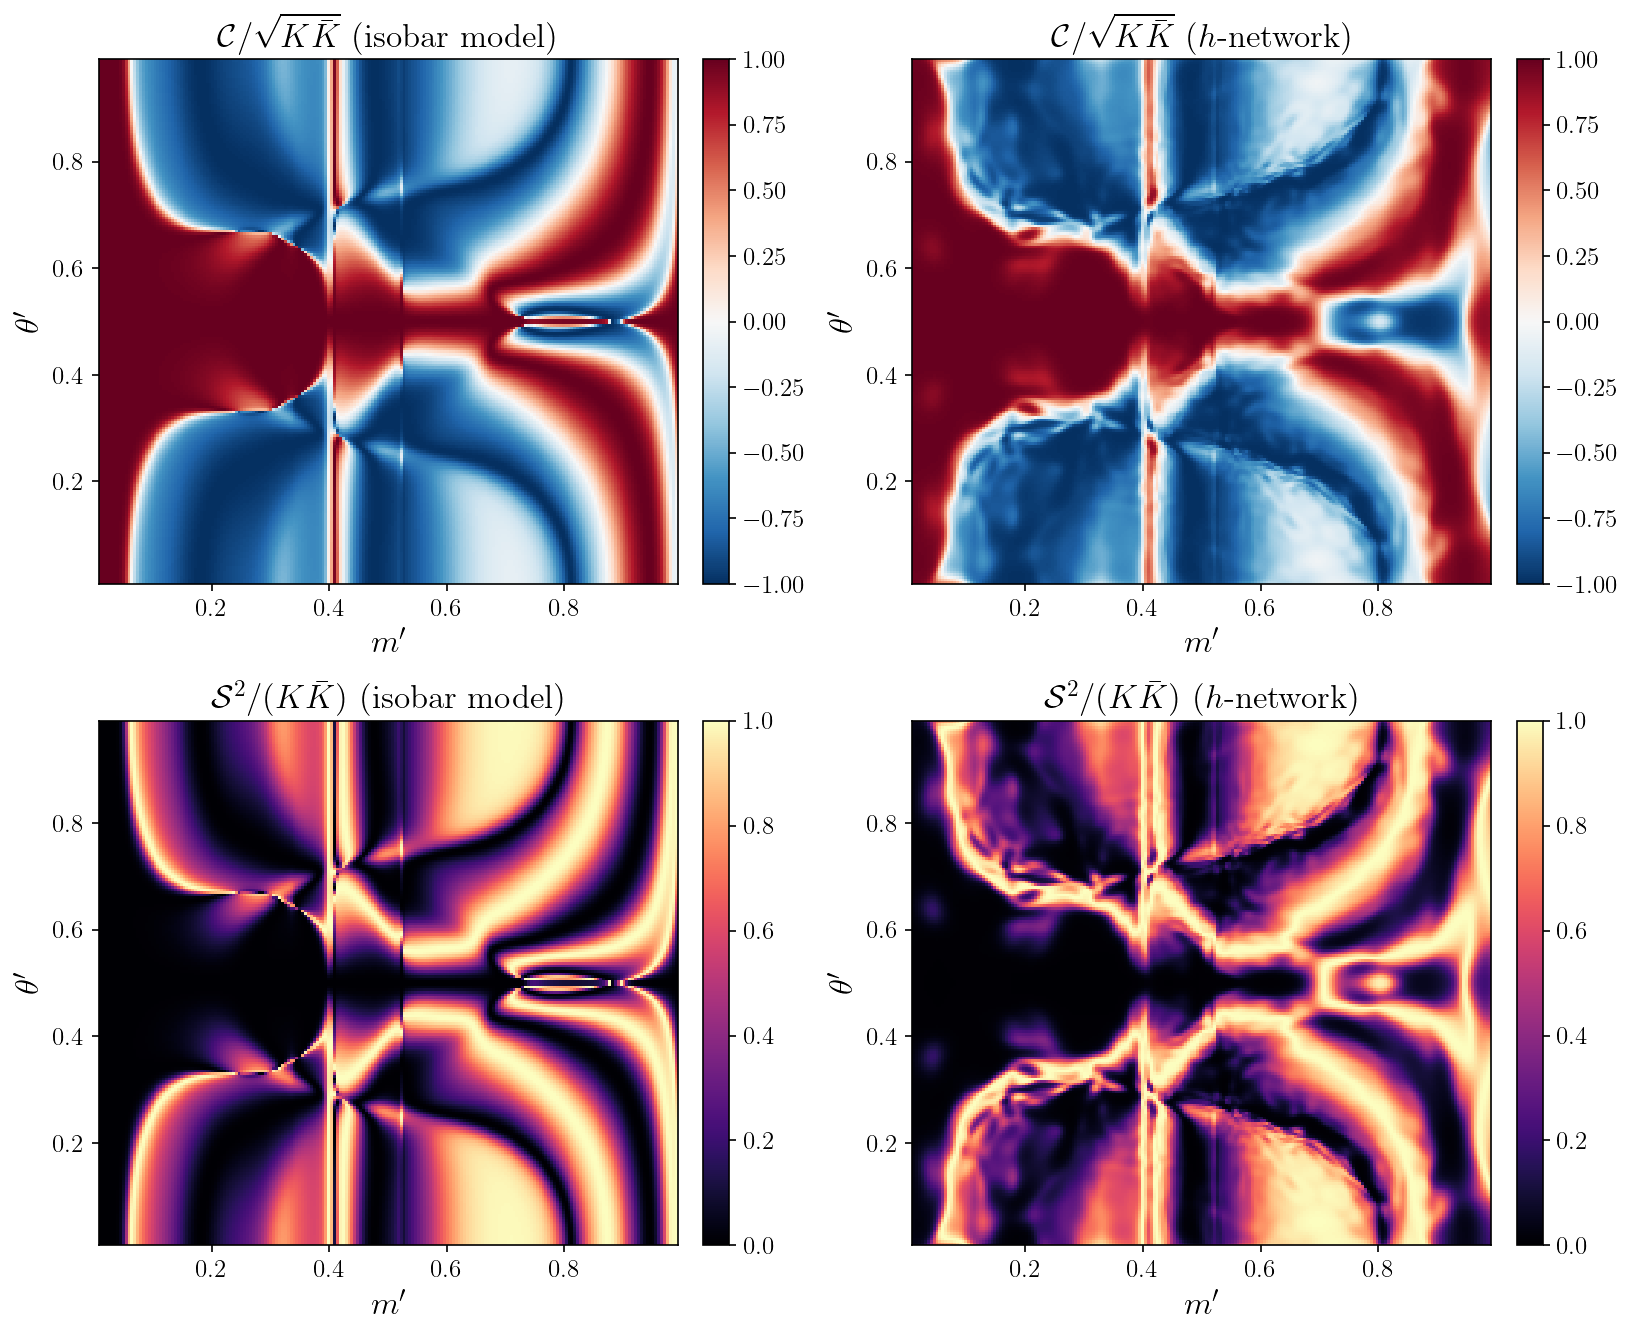

In [6]:
# NOTE: C_exact is in DP units (|A|^2 scale) while C_hnet is in SDP units (flow density scale).
# To compare shapes, normalize both by their respective alpha:
#   C_exact / alpha_exact = cos(delta_D)
#   C_hnet / alpha_hnet = h
# Or compare C/alpha directly. But for a visual comparison matching San's figure,
# we normalize both to the same scale.

alpha_exact = np.abs(A12) * np.abs(A13)
cos_dd_exact = C_exact / (alpha_exact + 1e-30)
S2_norm_exact = S2_exact / (alpha_exact**2 + 1e-30)  # = sin^2(delta_D)

cos_dd_hnet = h_v  # h IS cos(delta_D)
S2_norm_hnet = 1.0 - h_v**2  # = sin^2(delta_D) by construction

# Plot
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

def hmap(ax, data, title, cmap='RdBu_r', vmin=-1, vmax=1):
    im = ax.pcolormesh(ms, ts, data.reshape(N, N), cmap=cmap, vmin=vmin, vmax=vmax,
                       shading='auto', rasterized=True)
    ax.set_xlabel(r"$m'$")
    ax.set_ylabel(r"$\theta'$")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

hmap(axes[0, 0], cos_dd_exact, r'$\mathcal{C}/\sqrt{K\bar{K}}$ (isobar model)')
hmap(axes[0, 1], cos_dd_hnet,  r'$\mathcal{C}/\sqrt{K\bar{K}}$ ($h$-network)')
hmap(axes[1, 0], S2_norm_exact, r'$\mathcal{S}^2 / (K\bar{K})$ (isobar model)', cmap='magma', vmin=0, vmax=1)
hmap(axes[1, 1], S2_norm_hnet,  r'$\mathcal{S}^2 / (K\bar{K})$ ($h$-network)', cmap='magma', vmin=0, vmax=1)

plt.tight_layout()
for ext in ['pdf', 'png']:
    plt.savefig(os.path.join(FIGURES_DIR, f'C_S2_comparison_hnet.{ext}'), bbox_inches='tight', dpi=300)
plt.show()

## 4. C and S² Heatmaps (unnormalized, matching 3-flow figure style)

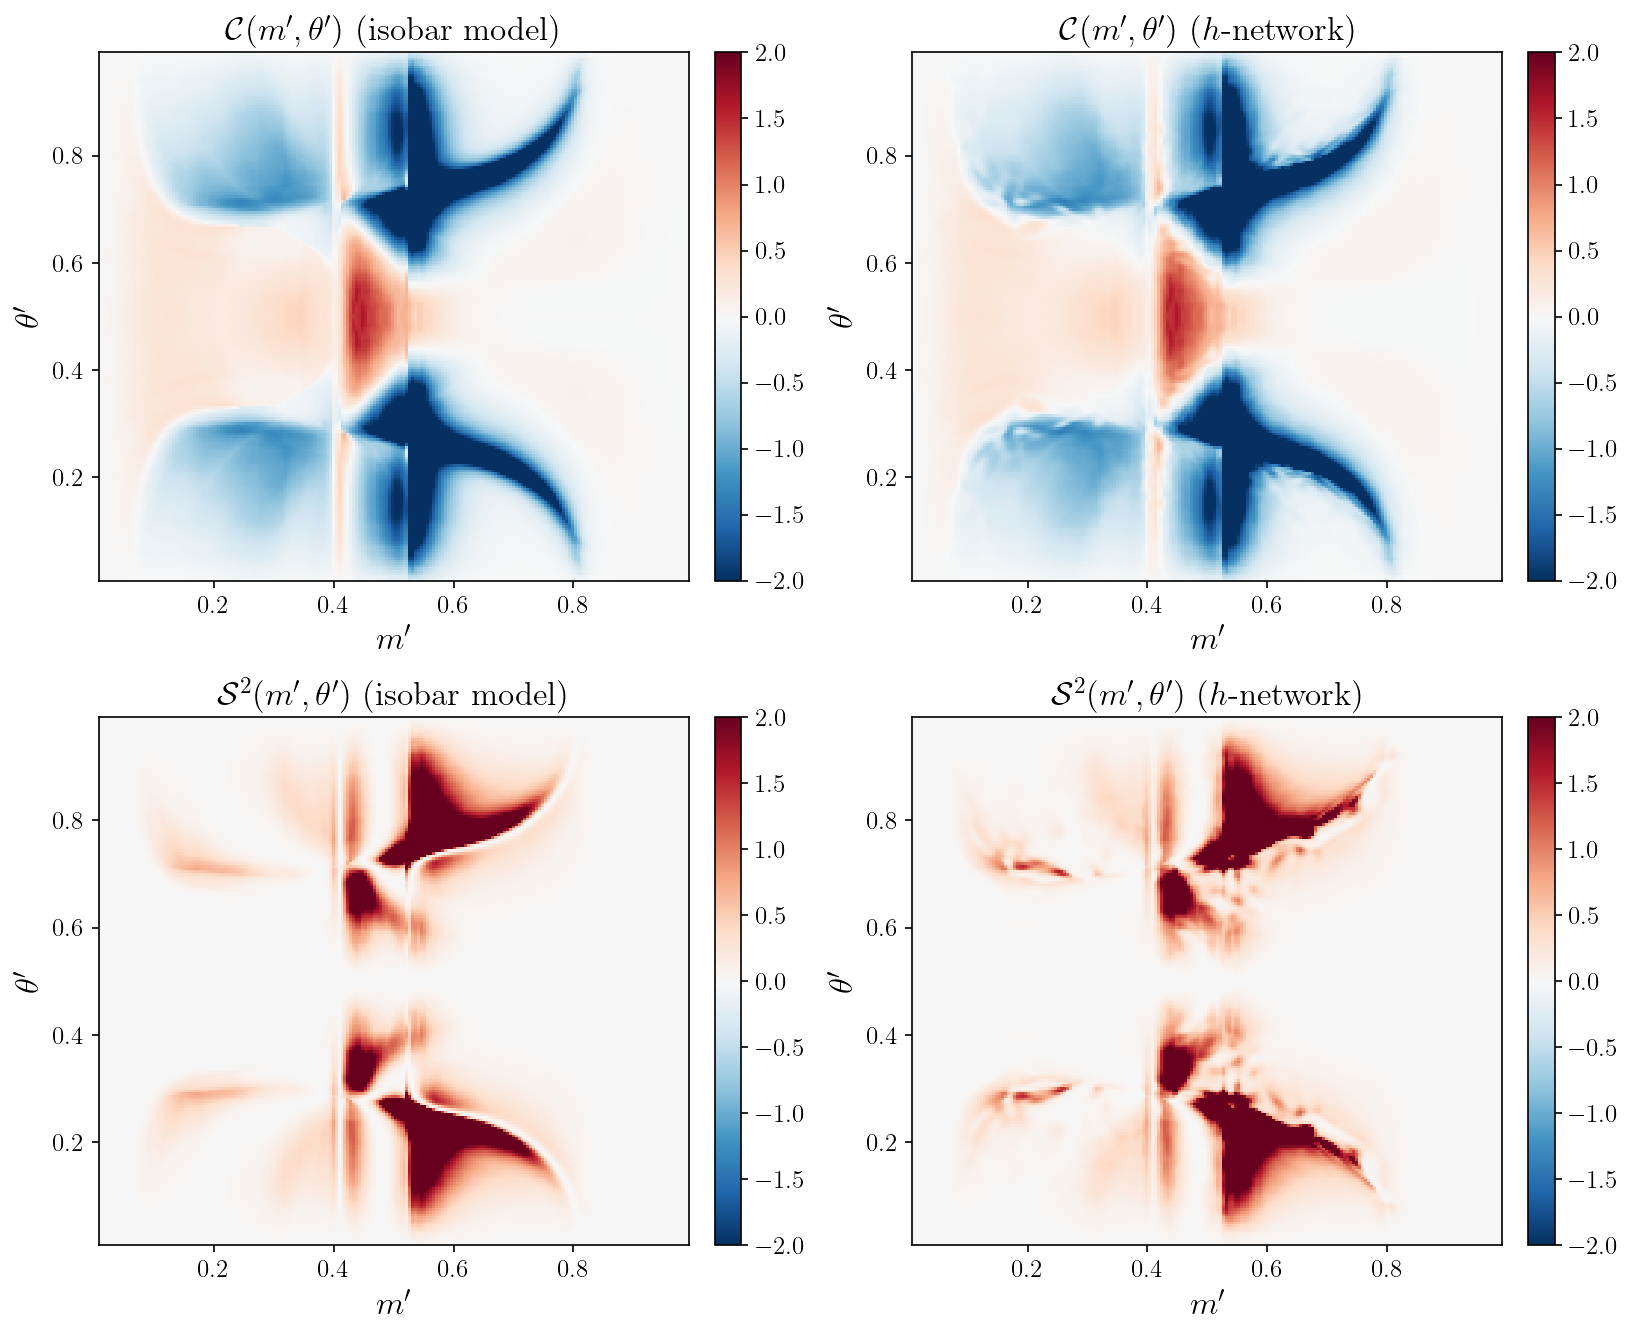

In [9]:
# Unnormalized C and S^2 in SDP measure, both on the same scale.
# The exact C = Re(A12 * conj(A13)) is in DP units.
# The h-network C = alpha_flow * h is in SDP flow units.
# To put exact on the same scale, we normalize: C_exact_scaled = C_exact * (alpha_flow / alpha_exact)
# This preserves the SHAPE while matching the SCALE of the flow.

alpha_exact = np.abs(A12) * np.abs(A13)
alpha_flow = np.sqrt(np.maximum(pF * pFsw, 0.0))

# Scale exact to match flow normalization (per-point rescaling)
scale = alpha_flow / (alpha_exact + 1e-30)
C_exact_scaled = C_exact * scale
S2_exact_scaled = S2_exact * scale**2

# h-network C and S^2 already in flow scale
# C_hnet and S2_hnet defined above

# Use symmetric colorbar for S^2 to show that the h-network never goes negative
# (unlike the 3-flow which can produce S^2 < 0 from constraint violations)
C_lim = 2.0
S2_lim = 2.0  # symmetric range to highlight absence of negative regions

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

def hmap2(ax, data, title, cmap='RdBu_r', vmin=None, vmax=None):
    im = ax.pcolormesh(ms, ts, data.reshape(N, N), cmap=cmap, vmin=vmin, vmax=vmax,
                       shading='auto', rasterized=True)
    ax.set_xlabel(r"$m'$")
    ax.set_ylabel(r"$\theta'$")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

hmap2(axes[0, 0], C_exact_scaled, r'$\mathcal{C}(m^\prime,\theta^\prime)$ (isobar model)', vmin=-C_lim, vmax=C_lim)
hmap2(axes[0, 1], C_hnet,         r'$\mathcal{C}(m^\prime,\theta^\prime)$ ($h$-network)', vmin=-C_lim, vmax=C_lim)
hmap2(axes[1, 0], S2_exact_scaled, r'$\mathcal{S}^2(m^\prime,\theta^\prime)$ (isobar model)', vmin=-S2_lim, vmax=S2_lim)
hmap2(axes[1, 1], S2_hnet,         r'$\mathcal{S}^2(m^\prime,\theta^\prime)$ ($h$-network)', vmin=-S2_lim, vmax=S2_lim)

plt.tight_layout()
for ext in ['pdf', 'png']:
    plt.savefig(os.path.join(FIGURES_DIR, f'C_S2_comparison_hnet_unnorm.{ext}'), bbox_inches='tight', dpi=300)
plt.show()